# Entendimento dos Dados (EDA)

# Importando bibliotecas

- Todas as bibliotecas estão disponíveis para download em projeto-final-rh-analytics/techcorp_attrition/requirements.txt
- O ambiente virtual foi instalado com a versão mais recente do python - 3.14.5

### Passos para criação do Kernel VSCode
Rode os seguintes comandos - supondo que já realizou a criação do ambiente virtual
- Ativar o ambiente virtual (se ainda não estiver ativo): .venv\Scripts\activate
- Instalar o ipykernel no ambiente: pip install ipykernel
- Registrar o kernel no Jupyter: python -m ipykernel install --user --name=XXnome-venvXX --display-name "Python xx.xx.xx (meu-projeto)"
- Verificar se o kernel foi registrado: jupyter kernelspec list
- Remover o kernel quando não precisar mais: jupyter kernelspec remove meu-projeto


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid", context="notebook")

# 1 - Carregamento dos dados

In [2]:
# Carregando o dataset
df = pd.read_csv('../data/raw/ibm_hr_analytics_sintetico.csv')

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

Dimensões do dataset: 50000 linhas x 35 colunas


# 2 - Análise Exploratória Inicial

In [3]:
# Primeira visualização
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,33,No,Non-Travel,745,Human Resources,7,4,Life Sciences,1,1,2,Female,100,2,3,Human Resources,3,Divorced,10606,12568,2,Y,Yes,21,4,2,80,0,13,1,3,13,0,13,5
1,31,No,Travel_Rarely,1039,Sales,14,4,Marketing,1,2,2,Female,45,2,1,Sales Representative,2,Married,3134,4339,2,Y,No,11,3,1,80,0,5,5,2,5,4,4,0
2,38,Yes,Travel_Rarely,850,Sales,29,2,Marketing,1,3,3,Male,87,3,2,Sales Executive,3,Married,8986,13671,4,Y,Yes,17,3,3,80,0,19,4,3,9,6,5,6
3,45,No,Travel_Rarely,678,Research & Development,8,2,Technical Degree,1,4,3,Male,65,3,3,Research Scientist,4,Married,10482,14954,3,Y,Yes,18,3,3,80,1,18,1,4,6,6,6,0
4,36,No,Travel_Rarely,890,Human Resources,14,3,Human Resources,1,5,2,Male,94,4,2,Human Resources,3,Married,6948,12051,2,Y,Yes,17,4,3,80,2,7,2,1,1,0,0,0


#### Describe do dataframe

**Describe para variáveis numéricas**

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.0,37.05862,8.837252,18.0,31.00,37.0,43.00,60.0
DailyRate,50000.0,798.43296,371.889604,100.0,527.00,798.0,1069.00,1500.0
DistanceFromHome,50000.0,9.55678,6.479495,1.0,5.00,8.0,13.00,29.0
Education,50000.0,2.90082,1.056847,1.0,2.00,3.0,4.00,5.0
EmployeeCount,50000.0,1.00000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,50000.0,25000.50000,14433.901067,1.0,12500.75,25000.5,37500.25,50000.0
EnvironmentSatisfaction,50000.0,2.77096,1.084382,1.0,2.00,3.0,4.00,4.0
HourlyRate,50000.0,65.62990,18.610526,30.0,52.00,66.0,79.00,100.0
JobInvolvement,50000.0,2.76146,0.830983,1.0,2.00,3.0,3.00,4.0
JobLevel,50000.0,2.50388,1.037616,1.0,2.00,2.0,3.00,5.0


**Describe para variáveis categóricas**

In [5]:
df.describe(include='object').T

,count,unique,top,freq
Attrition,50000,2,No,43706
BusinessTravel,50000,3,Travel_Rarely,35041
Department,50000,3,Research & Development,32385
EducationField,50000,6,Life Sciences,15504
Gender,50000,2,Male,29885
JobRole,50000,9,Research Scientist,10956
MaritalStatus,50000,3,Married,31121
Over18,50000,1,Y,50000
OverTime,50000,2,No,38096


#### Validações adicionais

In [6]:
def dataframe_overview(data):
    overview = pd.DataFrame({
        "data_type": data.dtypes.astype(str),
        "qtd_value_unique": data.nunique(),
        "missing": data.isna().sum(),
        "missing_pct": data.isna().mean() * 100,
        "duplicated_values": [data[col].duplicated().sum() for col in data.columns]
    })
    return overview.sort_values(["missing_pct", "qtd_value_unique"], ascending=[False, True])

overview = dataframe_overview(df)
overview

,data_type,qtd_value_unique,missing,missing_pct,duplicated_values
EmployeeCount,int64,1,0,0.0,49999
Over18,str,1,0,0.0,49999
StandardHours,int64,1,0,0.0,49999
Attrition,str,2,0,0.0,49998
Gender,str,2,0,0.0,49998
OverTime,str,2,0,0.0,49998
PerformanceRating,int64,2,0,0.0,49998
BusinessTravel,str,3,0,0.0,49997
Department,str,3,0,0.0,49997
MaritalStatus,str,3,0,0.0,49997


##### **Variáveis desnecessárias**:

Variáveis que são irrelevantes para predição do modelo:
- EmployeeCount: valor 1 para todos, não agrega informação
- StandardHours: valor 80 para todos, não agrega informação
- Over18: valor "Y" para todos, não agrega informação
- EmployeeNumber: Identificador único, não é uma feature. A presença de identificadores únicos pode levar ao data leakage, onde o modelo memoriza resultados do conjunto de treino que não se repetirão no conjunto de validação ou produção, mascarando a real eficácia do algoritmo.

In [7]:
# Retirando colunas desnecessárias
df_raw = df.copy()
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

print(df.shape)

(50000, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,33,No,Non-Travel,745,Human Resources,7,4,Life Sciences,2,Female,100,2,3,Human Resources,3,Divorced,10606,12568,2,Yes,21,4,2,0,13,1,3,13,0,13,5
1,31,No,Travel_Rarely,1039,Sales,14,4,Marketing,2,Female,45,2,1,Sales Representative,2,Married,3134,4339,2,No,11,3,1,0,5,5,2,5,4,4,0
2,38,Yes,Travel_Rarely,850,Sales,29,2,Marketing,3,Male,87,3,2,Sales Executive,3,Married,8986,13671,4,Yes,17,3,3,0,19,4,3,9,6,5,6
3,45,No,Travel_Rarely,678,Research & Development,8,2,Technical Degree,3,Male,65,3,3,Research Scientist,4,Married,10482,14954,3,Yes,18,3,3,1,18,1,4,6,6,6,0
4,36,No,Travel_Rarely,890,Human Resources,14,3,Human Resources,2,Male,94,4,2,Human Resources,3,Married,6948,12051,2,Yes,17,4,3,2,7,2,1,1,0,0,0


#### Criando variável binária para Attrition

In [8]:
df_eda = df.copy()
df_eda["AttritionFlag"] = (df_eda["Attrition"] == "Yes").astype(int)

#### Peso da target

In [29]:
# Quantidade de registros agrupando por Yes e No
print(df_eda['Attrition'].value_counts())
print()
# Porcentagem dos registros agrupando por Yes e No
print(df_eda['Attrition'].value_counts(normalize=True))

Attrition
No     43706
Yes     6294
Name: count, dtype: int64

Attrition
No     0.87412
Yes    0.12588
Name: proportion, dtype: float64


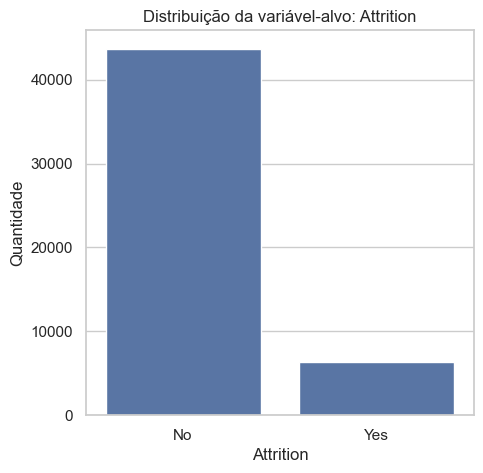

In [56]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df_eda, x="Attrition")
plt.title("Distribuição da variável-alvo: Attrition")
plt.xlabel("Attrition")
plt.ylabel("Quantidade")
plt.savefig('../reports/distribuicao_variavel_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

**A target está desbalanceada**

Definimos a coluna Attrition como target, pois o modelo indica se o colaborador teve um desligamento ou não. Como observado nos dados e gráficos anteriores, há um desbalanceamento considerável entre as classes. Conforme observado, o conjunto de dados apresenta um desbalanceamento significativo, com cerca de 87% dos funcionários mantendo o vínculo e apenas 12% registrando a saída.

|Attrition | % |
|--|--|
|No | 87,41% |
|Yes | 12,58% |

Ao desenvolver o modelo, este desbalanceamento exige atenção redobrada. Caso não seja tratado, o algoritmo terá dificuldade em prever a classe minoritária ('Yes'). Esse ponto é crucial e alinha-se ao que foi levantado na etapa de Business Understanding: para a empresa, o prejuízo é maior quando o modelo prevê que o funcionário permanecerá, mas ele acaba saindo (falso negativo). Nosso objetivo é otimizar o modelo para minimizar esses erros, aumentando a assertividade na identificação de colaboradores em risco de desligamento.


# 3 - Distribuição das Variáveis Numéricas

## Por que analisar a distribuição das variáveis numéricas?


Antes de usar qualquer variável no modelo, você precisa **conhecê-la**.
A distribuição te responde 4 perguntas fundamentais:

---

### 1. A variável tem outliers?

```
Exemplo: MonthlyIncome
Maioria dos funcionários: R$ 3.000 - R$ 15.000
Um registro:             R$ 250.000  ← outlier

Impacto no modelo: a Regressão Logística é sensível a outliers
→ esse valor extremo pode distorcer os coeficientes do modelo
```

---

### 2. Qual é o formato da distribuição?

```
Normal (simétrica)     →  a maioria no centro, poucos nas extremidades
Assimétrica à direita  →  maioria com valores baixos, poucos com valores altos
Bimodal                →  dois picos → pode indicar dois grupos distintos
```

> Isso importa porque o `StandardScaler` assume distribuição aproximadamente normal.
> Se a distribuição for muito assimétrica, pode ser necessário aplicar uma transformação antes.

---

### 3. A variável realmente é numérica contínua ou é ordinal disfarçada?

```
JobSatisfaction:  valores 1, 2, 3, 4
→ parece número mas significa: Baixo, Médio, Alto, Muito Alto
→ tratar como número puro pode fazer o modelo entender que
  a diferença entre 1 e 2 é igual à diferença entre 3 e 4
→ precisa de tratamento especial no pré-processamento
```

---

### 4. As distribuições são diferentes entre quem saiu e quem ficou?

```
Exemplo: Age
  Ficou:  média 38 anos  ──────█████──────
  Saiu:   média 29 anos  ────█████────────
                                  ↑
                         diferença visível!
→ Age provavelmente é uma boa feature para o modelo
```

> Se as distribuições forem **iguais** entre quem saiu e quem ficou,
> a variável provavelmente **não vai ajudar** o modelo a distinguir os dois grupos.

---

### Resumindo — o que a análise de distribuição nos entrega

| O que analisamos | Decisão que isso gera |
|---|---|
| Outliers | Tratar ou não na Etapa 3 |
| Formato da distribuição | Aplicar transformação ou não |
| Ordinal vs contínua | Definir encoding correto |
| Diferença entre grupos | Selecionar ou descartar features |

---

> Você não está fazendo gráficos bonitos por fazer —
> cada visualização vai **informar uma decisão concreta**
> no pré-processamento e na seleção de features.

##   

In [50]:
feature_cols = [c for c in df_eda.columns if c not in ["Attrition", "AttritionFlag"]]

num_cols = df_eda[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = df_eda[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print(f"Numéricas: {num_cols}")
print(f"Categóricas: {cat_cols}")

Numéricas: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categóricas: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [49]:
print(f'Total de variáveis categóricas: {len(cat_cols)}')
print(f'Total de variáveis numéricas: {len(num_cols)}')

Total de variáveis categóricas: 7
Total de variáveis numéricas: 23


## Variáveis Ordinais Disfarçadas de Número

Dentre as 23 variáveis numéricas identificadas, as seguintes são **escalas ordinais**
— possuem ordem, mas a distância entre os valores não é necessariamente igual:

| Variável | Valores | O que significa |
|---|---|---|
| `Education` | 1-5 | 1=Abaixo da faculdade … 5=Doutorado |
| `EnvironmentSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `JobInvolvement` | 1-4 | 1=Baixo … 4=Muito Alto |
| `JobLevel` | 1-5 | Nível hierárquico |
| `JobSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `PerformanceRating` | 1-4 | 1=Baixo … 4=Excelente |
| `RelationshipSatisfaction` | 1-4 | 1=Baixo … 4=Muito Alto |
| `StockOptionLevel` | 0-3 | Nível de opções de ações |
| `WorkLifeBalance` | 1-4 | 1=Ruim … 4=Excelente |

In [51]:
# Numéricas contínuas reais
num_continuas = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                 'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
                 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                 'YearsWithCurrManager']

# Escalas ordinais disfarçadas de número
num_ordinais = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                'JobLevel', 'JobSatisfaction', 'PerformanceRating',
                'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

print(f"Contínuas: {len(num_continuas)}")
print(f"Ordinais:  {len(num_ordinais)}")

Contínuas: 14
Ordinais:  9


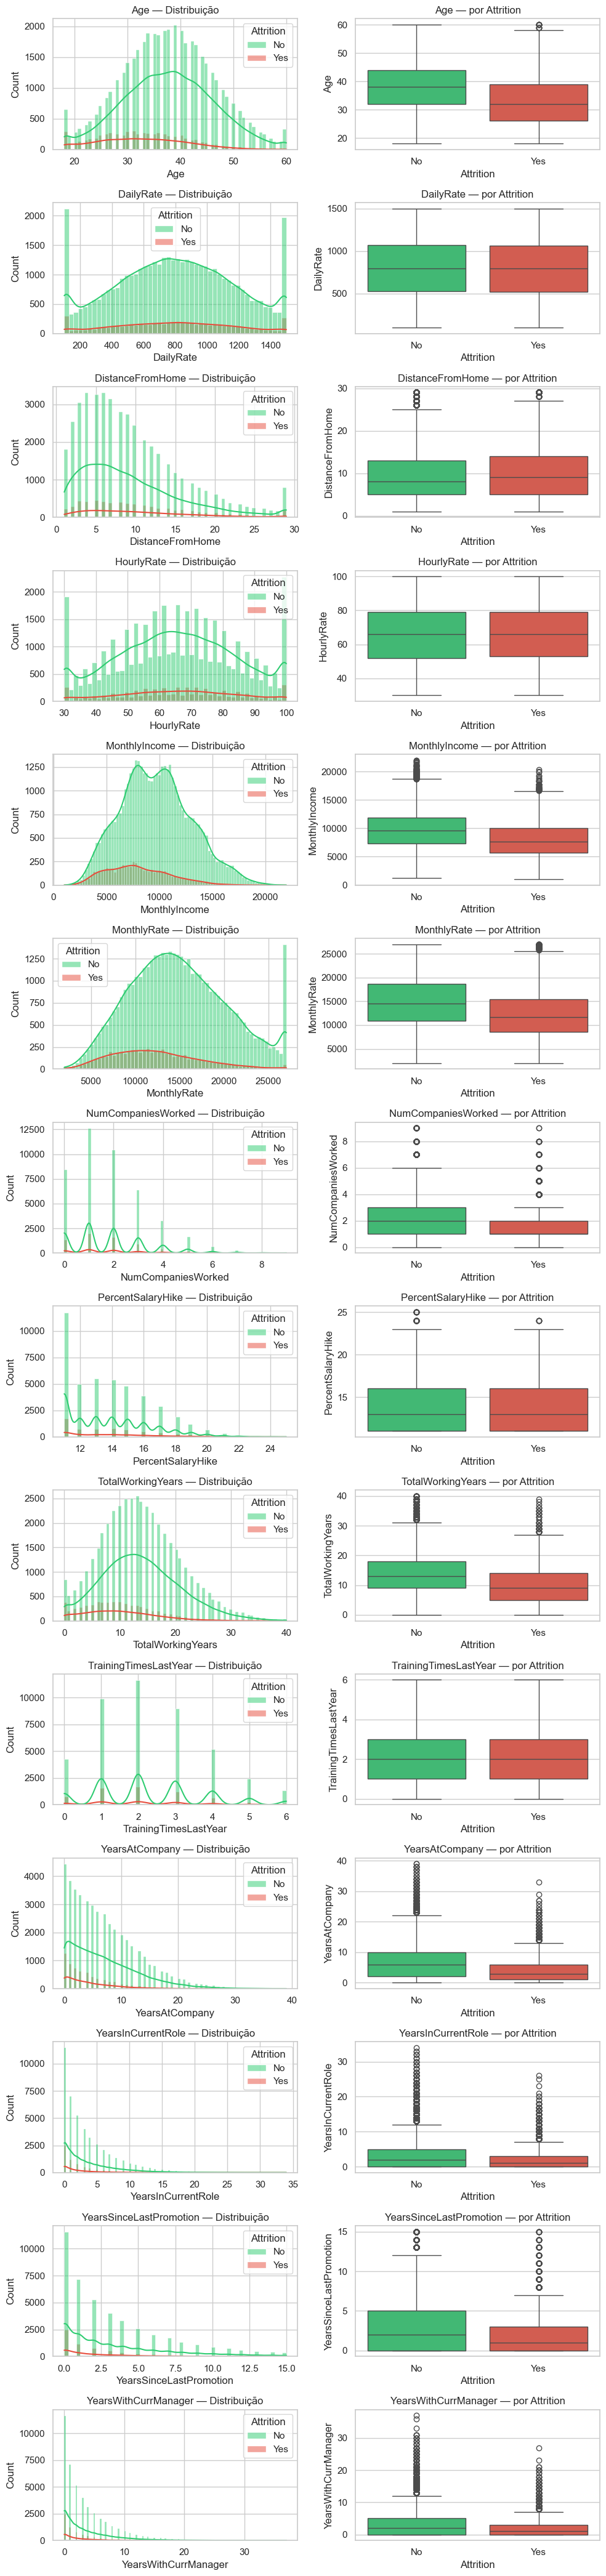

In [53]:
# Plotar o gráfico de distribvuições apenas para variáveis contínuas

fig, axes = plt.subplots(len(num_continuas), 2, figsize=(10, len(num_continuas) * 3))

for i, col in enumerate(num_continuas):
    # Histograma
    sns.histplot(data=df_eda, x=col, hue='Attrition', kde=True,
                 ax=axes[i, 0], palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
    axes[i, 0].set_title(f'{col} — Distribuição')

    # Boxplot
    sns.boxplot(data=df_eda, x='Attrition', y=col,
                ax=axes[i, 1], palette={'Yes': '#e74c3c', 'No': '#2ecc71'})
    axes[i, 1].set_title(f'{col} — por Attrition')

plt.tight_layout()
plt.savefig('../reports/distribuicao_variaveis_continuas.png', dpi=150, bbox_inches='tight')
plt.show()